# Barcode & QR Code Scanning with MATA

Demonstrates reading **1D barcodes and QR codes** from images using MATA's
`barcode` task. Two backend engines are supported — choose the one that fits
your environment:

| Engine | Install | Strengths |
|--------|---------|-----------|
| `pyzbar` | `pip install datamata[barcode]` | Fast, CPU-only, widely used |
| `zxing` | `pip install datamata[barcode-zxing]` | More symbologies, pure Python |

**Prerequisites**:
```bash
pip install datamata[barcode]          # pyzbar (default)
pip install datamata[barcode-zxing]    # zxing-cpp (alternative)
pip install datamata[barcode-all]      # both engines
```

Sample images (`sample_barcode.jpg`, `sample_qr.jpg`, `sample_graph_barcode.png`)
are bundled in the repository under `examples/images/`.

In [1]:
# Uncomment to install:
# !pip install datamata[barcode]        # pyzbar
# !pip install datamata[barcode-zxing]  # zxing-cpp

In [ ]:
from pathlib import Path
import mata

print(f"MATA version: {mata.__version__}")

# Image paths (bundled with the repo)
IMAGES_DIR    = Path("../../examples/images")
BARCODE_IMAGE = str(IMAGES_DIR / "sample_barcode.jpg")
QR_IMAGE      = str(IMAGES_DIR / "sample_qr.jpg")
MULTI_IMAGE   = str(IMAGES_DIR / "sample_graph_barcode.png")

for label, p in [("Barcode", BARCODE_IMAGE), ("QR", QR_IMAGE), ("Multi", MULTI_IMAGE)]:
    status = "FOUND" if Path(p).exists() else "NOT FOUND"
    print(f"  {label:8s}: {status}  ({p})")

MATA version: 1.9.5
  Barcode : FOUND  (..\..\examples\images\sample_barcode.jpg)
  QR      : FOUND  (..\..\examples\images\sample_qr.jpg)
  Multi   : FOUND  (..\..\examples\images\sample_graph_barcode.png)


## 1. One-Shot Scan — `mata.run()`

The simplest usage: one call, no setup.  
`BarcodeResult` auto-renders as a rich HTML table in Jupyter.

In [38]:
result = mata.run("barcode", BARCODE_IMAGE, model="pyzbar")

# Auto-display: rich HTML table in Jupyter
result

[INFO] Loading barcode model from external_engine: pyzbar


Data,Type,Score,BBox
123456789,CODE_128,1.000,"(34, 11, 261, 188)"


In [4]:
# Inspect barcodes programmatically
print(f"Found {len(result.barcodes)} barcode(s):")
for bc in result.barcodes:
    print(f"  [{bc.type}] data={bc.data!r}  confidence={bc.score:.2f}")
    if bc.bbox:
        x1, y1, x2, y2 = bc.bbox
        print(f"    bbox: ({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})")
    if bc.raw_bytes:
        print(f"    raw hex: {bc.raw_bytes.hex()[:32]}...")

Found 1 barcode(s):
  [CODE_128] data='123456789'  confidence=1.00
    bbox: (34, 11, 261, 188)
    raw hex: 313233343536373839...


## 2. QR Codes

Same API — MATA auto-detects QR codes alongside 1D barcodes.

In [5]:
qr_result = mata.run("barcode", QR_IMAGE, model="pyzbar")

# Auto-display
qr_result

[INFO] Loading barcode model from external_engine: pyzbar


Data,Type,Score,BBox
https://datamata.io,QR_CODE,1.000,"(42, 42, 289, 289)"


In [6]:
# Filter to QR codes only
qr_only = qr_result.filter_by_type("QR_CODE")
print(f"Total barcodes: {len(qr_result)},  QR codes only: {len(qr_only)}")

for bc in qr_only:
    print(f"  data={bc.data!r}")

Total barcodes: 1,  QR codes only: 1
  data='https://datamata.io'


## 3. Load Once, Predict Many

Load the adapter once for better performance when scanning multiple images.

In [7]:
adapter = mata.load("barcode", "pyzbar")

# Scan multiple images with the same adapter instance
images = [BARCODE_IMAGE, QR_IMAGE, MULTI_IMAGE]
for img_path in images:
    if not Path(img_path).exists():
        print(f"  [skip] {img_path}")
        continue
    r = adapter.predict(img_path)
    types = [bc.type for bc in r.barcodes]
    print(f"  {Path(img_path).name}: {len(r.barcodes)} barcode(s)  {types}")

[INFO] Loading barcode model from external_engine: pyzbar
  sample_barcode.jpg: 1 barcode(s)  ['CODE_128']
  sample_qr.jpg: 1 barcode(s)  ['QR_CODE']
  sample_graph_barcode.png: 6 barcode(s)  ['QR_CODE', 'QR_CODE', 'CODE_128', 'CODE_128', 'CODE_128', 'CODE_128']


## 4. Switch Engines — pyzbar vs zxing-cpp

Try both engines on the same image and compare results.  
Install both with `pip install datamata[barcode-all]`.

In [8]:
engines = {
    "pyzbar": "pip install datamata[barcode]",
    "zxing":  "pip install datamata[barcode-zxing]",
}

for engine, install_hint in engines.items():
    try:
        r = mata.run("barcode", BARCODE_IMAGE, model=engine)
        print(f"[{engine}] {len(r.barcodes)} barcode(s)  engine={r.meta.get('engine', engine)}")
        for bc in r.barcodes:
            print(f"  [{bc.type}] {bc.data!r}")
    except ImportError as exc:
        print(f"[{engine}] not installed — {install_hint}")
        print(f"  ({exc})")

[INFO] Loading barcode model from external_engine: pyzbar
[pyzbar] 1 barcode(s)  engine=pyzbar
  [CODE_128] '123456789'
[INFO] Loading barcode model from external_engine: zxing
[zxing] 1 barcode(s)  engine=zxing
  [Code128] '123456789'


## 5. Multi-Barcode Image

Scan an image that contains multiple barcodes or a mix of 1D barcodes and QR codes.

In [9]:
multi_result = mata.run("barcode", MULTI_IMAGE, model="pyzbar")

# Auto-display — shows all decoded barcodes in a table
multi_result

[INFO] Loading barcode model from external_engine: pyzbar


Data,Type,Score,BBox
https://datamata.io,QR_CODE,1.000,"(44, 860, 291, 1107)"
https://datamata.io,QR_CODE,1.000,"(1079, 44, 1326, 291)"
171819202122,CODE_128,1.000,"(998, 787, 1225, 964)"
111213141516,CODE_128,1.000,"(646, 495, 873, 672)"
987654321,CODE_128,1.000,"(331, 265, 558, 442)"
123456789,CODE_128,1.000,"(34, 11, 261, 188)"


In [10]:
# Filter by symbology type
oned = multi_result.filter_by_type("EAN_13", "EAN_8", "CODE_128", "CODE_39", "UPC_A", "UPC_E")
qr   = multi_result.filter_by_type("QR_CODE")

print(f"Total: {len(multi_result)}  |  1D barcodes: {len(oned)}  |  QR codes: {len(qr)}")

Total: 6  |  1D barcodes: 4  |  QR codes: 2


## 6. Visualise Bounding Boxes

Draw decoded barcode regions on the source image using OpenCV.

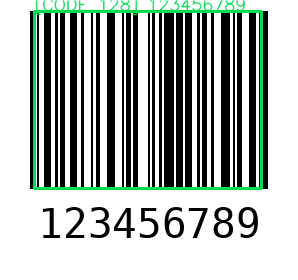

In [11]:
import cv2
from IPython.display import display
from PIL import Image as PILImage
import numpy as np

def draw_barcodes(image_path: str, scan_result) -> np.ndarray:
    """Draw bounding boxes and decoded text on the image."""
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for bc in scan_result.barcodes:
        if bc.bbox is None:
            continue
        x1, y1, x2, y2 = map(int, bc.bbox)
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 220, 80), 2)
        label = f"[{bc.type}] {bc.data[:30] if bc.data else ''}"
        cv2.putText(img_rgb, label, (x1, max(y1 - 8, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 220, 80), 1, cv2.LINE_AA)
    return img_rgb


annotated = draw_barcodes(BARCODE_IMAGE, result)
display(PILImage.fromarray(annotated))

## 7. Export Results

Save decoded barcodes to JSON or CSV.

In [12]:
from pathlib import Path

out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

# JSON string (preview)
json_str = result.to_json(indent=2)
print(f"JSON preview:\n{json_str[:300]}...\n")

# Save to file
result.save(str(out_dir / "barcodes.json"))
print(f"Saved: {out_dir / 'barcodes.json'}")

result.save(str(out_dir / "barcodes.csv"))
print(f"Saved: {out_dir / 'barcodes.csv'}")

JSON preview:
{
  "barcodes": [
    {
      "data": "123456789",
      "type": "CODE_128",
      "score": 1.0,
      "bbox": [
        34.0,
        11.0,
        261.0,
        188.0
      ],
      "raw_bytes": "313233343536373839"
    }
  ],
  "meta": {
    "engine": "pyzbar"
  }
}...

[INFO] Exported JSON to output\barcodes.json
Saved: output\barcodes.json
Saved: output\barcodes.csv


## 8. ROI Pipeline — Detect → Scan Crops

Use a zero-shot detector (Grounding DINO) to locate barcode regions first,
then scan only those crops. Useful when barcodes occupy a small area in a
large scene or when you need to correlate barcode data with detected objects.

> **Note**: requires `pip install datamata[detect]` and the Grounding DINO model.

In [69]:
#Uncomment to run — requires Grounding DINO and the graph API

from mata.nodes import Detect, ExtractROIs, Barcode, Fuse

graph = [
    Detect(using="gdino", out="dets", threshold=0.3,
            text_prompts="barcode banana"),
    ExtractROIs(src_dets="dets", out="rois"),
    Barcode(using="pyzbar", src="rois", out="codes"),
    Fuse(),
]

BANANA_IMAGE = str(IMAGES_DIR / "barcode" / "banana_barcode.png")

result_banana = mata.infer(
    BANANA_IMAGE,
    graph,
    providers={
        "detect":  {"gdino": mata.load("detect", "IDEA-Research/grounding-dino-tiny")},
        "barcode": {"pyzbar": mata.load("barcode", "pyzbar")},
    },
)
print(result_banana["dets"])

print("ROI pipeline cell — uncomment the code above to run.")

[INFO] Loading detect model from huggingface: IDEA-Research/grounding-dino-tiny
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceZeroShotDetectAdapter with device=cuda, threshold=0.3
[INFO] Detected zero-shot architecture: grounding_dino
[INFO] Loading GroundingDINO model: IDEA-Research/grounding-dino-tiny
[INFO] Successfully loaded grounding_dino on cuda
[INFO] Loading barcode model from external_engine: pyzbar
[INFO] Starting synchronous execution of graph 'untitled_graph'
[INFO] Graph 'untitled_graph' completed in 504.28ms (4 nodes)
Detections(instances=[Instance(score=0.4076502025127411, label=-1, bbox=(2.1907310485839844, 72.32059478759766, 1101.411376953125, 760.304931640625), mask=None, label_name='bar banana', area=None, is_stuff=None, embedding=None, track_id=None, keypoints=None)], instance_ids=['inst_0000'], entities=[], entity_ids=[], meta={'model_id': 'IDEA-Research/grounding-dino-tiny', 'architecture': 'grounding_dino', 'text_prompt

d:\Documents\OneDrive\Code\mtp\datamata_io\mata\.venv\Lib\site-packages\transformers\models\grounding_dino\processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


In [70]:
result_banana.codes


BarcodeData(entries=(BarcodeEntry(data='BAN_001', type='CODE_128', confidence=1.0, bbox=(393.0, 369.0, 646.0, 546.0)),), instance_ids=('inst_0000',), meta={})

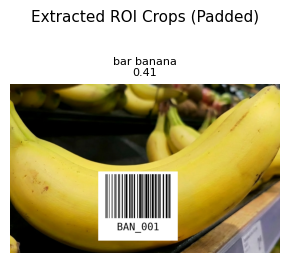

In [71]:

import matplotlib.pyplot as plt

rois_artifact = result_banana.rois
dets = result_banana.dets

n = len(rois_artifact.roi_images)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
if n == 1:
    axes = [axes]

for ax, roi, inst_id, inst in zip(axes, rois_artifact.roi_images, rois_artifact.instance_ids, dets.instances):
    ax.imshow(roi)
    ax.set_title(f"{inst.label_name}\n{inst.score:.2f}", fontsize=8)
    ax.axis("off")

plt.suptitle("Extracted ROI Crops (Padded)", fontsize=11)
plt.tight_layout()
plt.show()


[INFO] Visualizing 1 instances (VisionResult) with pil backend (alpha=0.5)


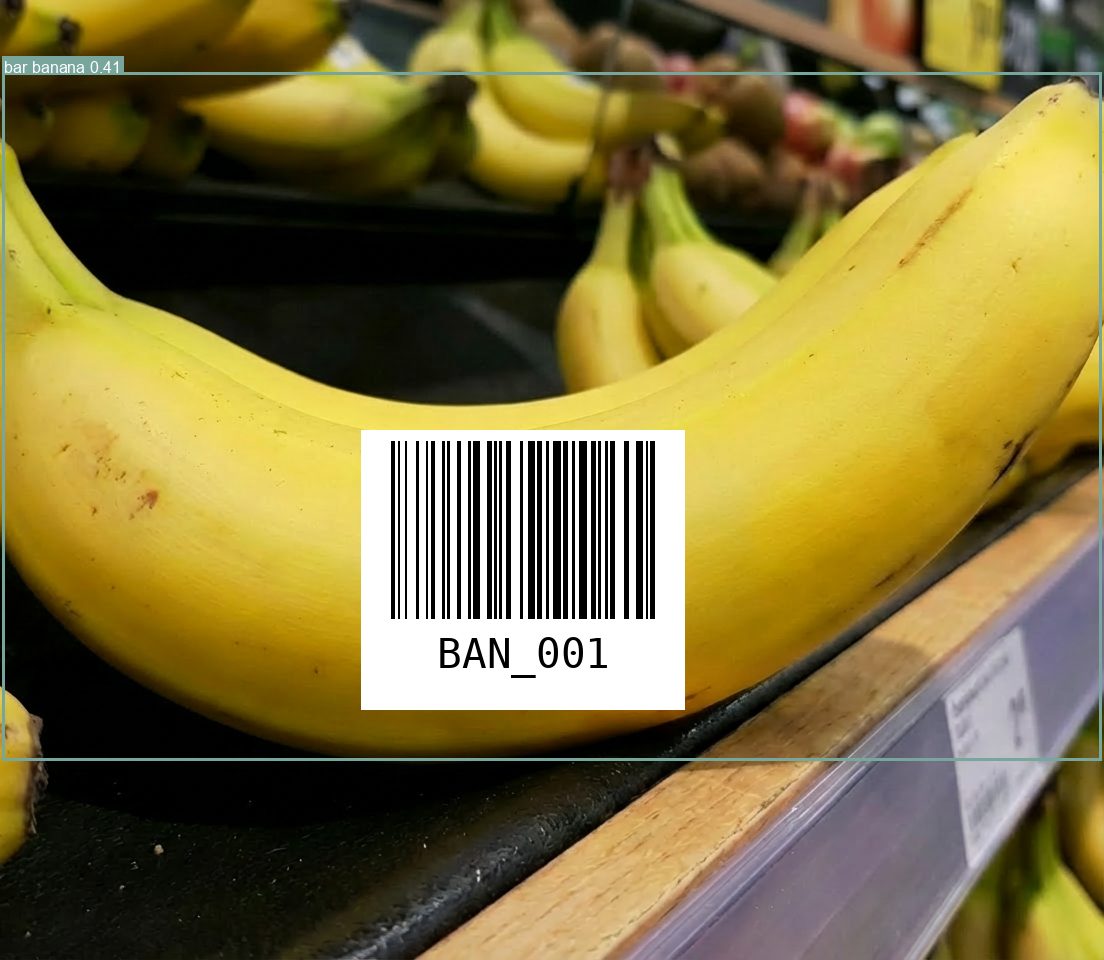

: 

In [ ]:
from mata.visualization import visualize_segmentation
from IPython.display import display

vis = visualize_segmentation(
    result_banana["dets"].to_vision_result(),
    image=BANANA_IMAGE,
    show_boxes=True, show_labels=True, show_scores=True,
)
display(vis)

## Notes

| API | Description |
|-----|-------------|
| `mata.run("barcode", img, model="pyzbar")` | One-shot scan, any image path/array |
| `mata.load("barcode", "pyzbar")` | Load adapter once for repeated use |
| `adapter.predict(img)` | Returns `BarcodeResult` |
| `result.barcodes` | List of `BarcodeData` objects |
| `bc.data` | Decoded string (UTF-8) |
| `bc.type` | Symbology: `QR_CODE`, `EAN_13`, `CODE_128`, … |
| `bc.score` | Confidence (0–1) |
| `bc.bbox` | `(x1, y1, x2, y2)` in pixel coords, or `None` |
| `bc.raw_bytes` | Raw decoded bytes |
| `result.filter_by_type(*types)` | Returns new `BarcodeResult` with matching types |
| `result.to_json()` | JSON string |
| `result.save("out.json")` | Save as JSON or CSV |

`BarcodeResult` auto-renders as a rich HTML table when evaluated in a notebook cell.